In [1]:
import os
import argparse
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from PIL import Image
from matplotlib import cm
import random
import sys
import cv2

eps = sys.float_info.epsilon
scale_up = 2
res = [2160, 1080]
random.seed(3)

In [2]:
populations_df = pd.read_csv("../out/populations.csv")
parent_df = pd.read_csv("../out/parent_tree.csv")
pop_sizes = populations_df[["Gen", "Pop"]].groupby("Gen", as_index=False).sum()
gen_count = pop_sizes["Gen"].max() + 1
max_pop = pop_sizes["Pop"].max()
print(f"Gens: {gen_count}, Max Pop {max_pop}")

Gens: 1450, Max Pop 868966


In [3]:
def build_tree(parent_df, parents, ids, roodId):
    tree = { cloneId: list(children) for cloneId in ids if \
        len(children := parent_df.loc[parent_df["ParentId"] == cloneId, "ChildId"]) > 0}   
    tree[-1] = [rootId]
    return tree

In [4]:
parents = parent_df["ParentId"].unique()
children = parent_df["ChildId"].unique()
root_list = np.setdiff1d(parents, children)
if len(root_list) != 1:
    raise Exception("Failed to determine root. There must be exactly one node with no parent in the parent tree.")
rootId = root_list[0]
ids = np.concatenate([[rootId], children])
tree = build_tree(parent_df, children, ids, rootId)

In [5]:
print(f"Parent tree has {len(tree)} nodes. Root is {rootId}")

Parent tree has 34 nodes. Root is 0


In [6]:
def line_from_data(px_row_orig, width):
    result = []
    pop_total = sum(row_it[0] for row_it in px_row_orig)
    px_row = [[px_row_orig[i][0] * width / pop_total, px_row_orig[i][1]] for i in range(len(px_row_orig))]
    contr = 1.0
    index = 0
    new_px = np.zeros(4)
    while index < len(px_row):
        if px_row[index][0] >= eps:
            factor = contr if px_row[index][0] >= contr else px_row[index][0]
            px_row[index][0] -= factor
            contr -= factor
            new_px += px_row[index][1] * factor
            if contr < eps:
                contr = 1.0
                result.append(new_px)
                new_px = np.zeros(4)
        else:
            index += 1
    if len(result) < width:
        result.append(new_px + contr * np.ones(4) * .5) # Adde gray to the last pixel if needed
    return result

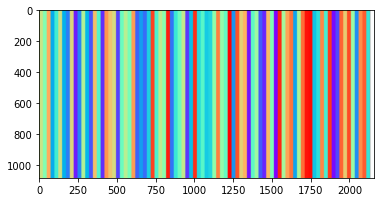

In [7]:
# Create Colors
cols = cm.rainbow(np.linspace(0, 1, len(ids))).tolist()
random.shuffle(cols)
col_map = {ids[i]: np.array(list(map(lambda x: (int)(x * 255), cols[i]))) for i in range(len(ids))}
col_map[-1] = np.ones(4) # Root is white 

# Display test colors
px_row = [[1, col_map[id]] for id in col_map]
test_px = line_from_data(px_row, res[1])
array = np.array([test_px] * res[0], dtype=np.uint8)
resized = cv2.resize(array, res)
new_image = Image.fromarray(resized)
plt.imshow(new_image)

In [8]:
def get_pop_dict(pops_df, gen, max_pop, normalize):
    test_pop = pops_df[pops_df["Gen"] == gen]
    pop_dict = { test_pop["Id"].iat[i]: test_pop["Pop"].iat[i] for i in range(len(test_pop))}
    if not normalize:
        pop_count = pops_df[pops_df["Gen"] == gen]["Pop"].sum()
        remainder = max_pop - pop_count
        pop_dict[-1] = remainder
    return pop_dict

def rec_descend(tree, pop_dict, cloneId):
    res = []
    if cloneId in tree:
        if cloneId in pop_dict:
            pop = pop_dict[cloneId] / 2
            res += [(pop, cloneId)]
            for childId in tree[cloneId]:
                res += rec_descend(tree, pop_dict, childId) 
            res += [(pop, cloneId)]
        else: 
            for childId in tree[cloneId]:
                res += rec_descend(tree, pop_dict, childId) 
    elif cloneId in pop_dict:
        return [(pop_dict[cloneId], cloneId)]
    return res

def get_image_pixels(tree, rootId, pop_df, col_map, breath, max_pop, normalize = True):
    img_pixels = []
    for i in range(0, gen_count):
        pop_dict = get_pop_dict(pop_df, i, max_pop, normalize)
        id_rows = rec_descend(tree, pop_dict, rootId if normalize else -1)
        pixel_row = [(id_row[0], col_map[id_row[1]]) for id_row in id_rows]
        line_px = line_from_data(pixel_row, res[1] * scale_up)
        img_pixels.append(line_px)
    return img_pixels

def pixels_to_img(img_pixels, res):
    px_array = np.array(img_pixels, dtype=np.uint8)
    resized = cv2.resize(px_array, [res[1], res[0]]) # Switch coordintaes as it's before the rotation
    new_image = Image.fromarray(resized).transpose(Image.ROTATE_270).transpose(Image.FLIP_LEFT_RIGHT)
    return new_image

In [9]:
# # Test
test_pop_d = get_pop_dict(populations_df, 0, max_pop, True)
line = rec_descend(tree, test_pop_d, rootId)

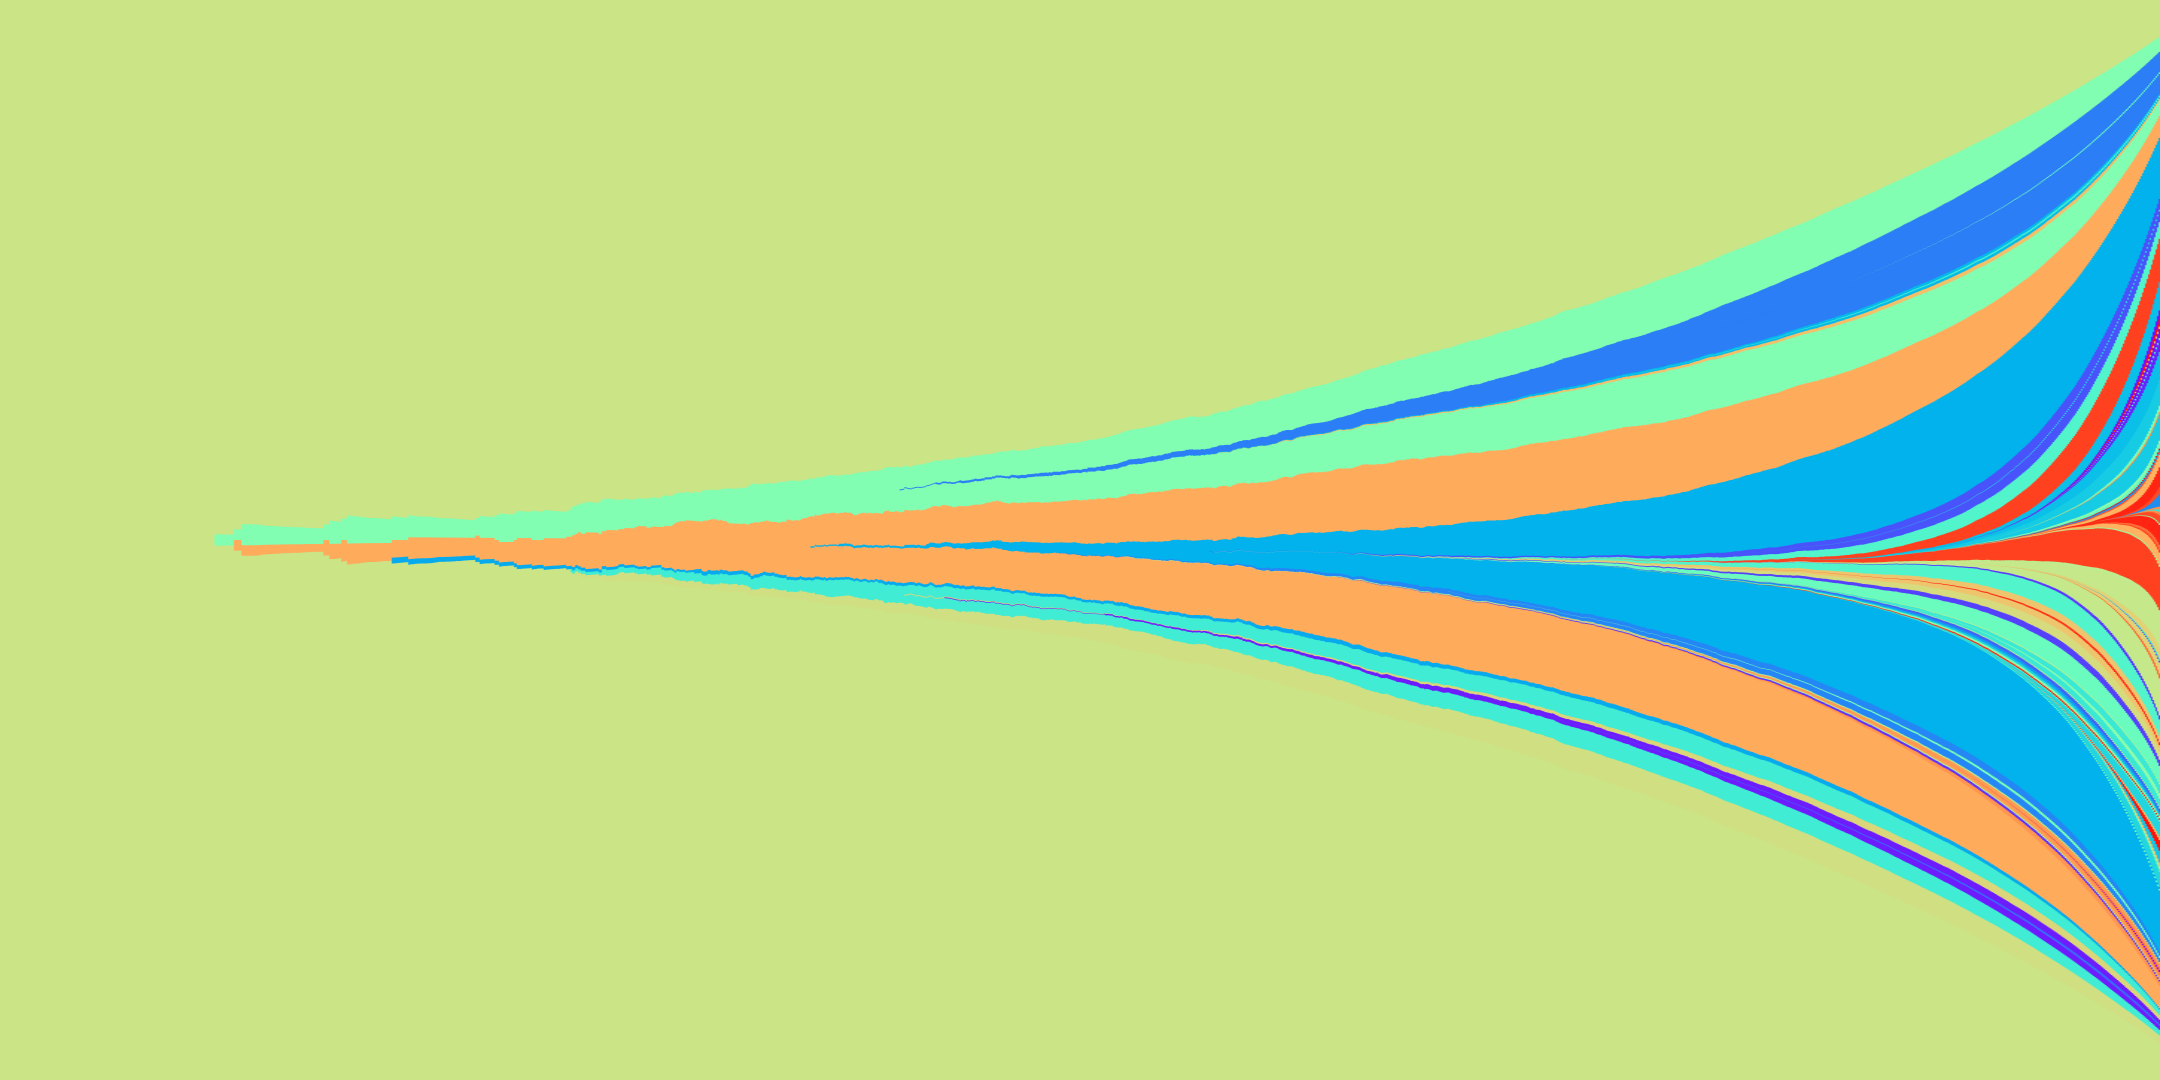

In [10]:
img_pixels = get_image_pixels(tree, rootId, populations_df, col_map, res[1] * scale_up, max_pop, True)
pixels_to_img(img_pixels, res)